# Finotello layer sweep

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
sys.path.append('../../deconversation')
from pseudobulk import *
from preprocessing import *
from embeddings_1 import *
from deconvolution import *
from visualization import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [5]:
dataset_name = 'finotello'
reference_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_signature_matrix_broad_id.csv'
bulk_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/finotello/finotello_tpm_id_transpose.csv'
ground_truth_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/finotello/finotello_facs.csv'

# Load signature
signature_df = pd.read_csv(reference_path, index_col=0)

# Load  bulk
bulk_df = pd.read_csv(bulk_path, index_col=0)

# Load ground truth
ground_truth = pd.read_csv(ground_truth_path, index_col=0)
ground_truth = ground_truth.T

In [22]:
def harmonize_columns(df):
    df = df.copy()
    if 'T cells CD8' in df.columns and 'T cells CD4 conv' in df.columns and 'Tregs' in df.columns:
        df['T cells'] = df['T cells CD8'] + df['T cells CD4 conv'] + df['Tregs']
        df = df.drop(columns=['T cells CD8', 'T cells CD4 conv', 'Tregs'])
    if 'pDC' in df.columns and 'mDC' in df.columns:
        df['mDC'] = df['mDC'] + df['pDC']
        df = df.drop(columns=['pDC'])
    elif 'pDC' in df.columns:
        df = df.rename(columns={'pDC': 'mDC'})
    return df

In [26]:
ground_truth = harmonize_columns(ground_truth)

In [27]:
ground_truth.head()

,NK cells,B cells,mDC,Monocytes,Neutrophils,Other,T cells
pbmc_1,0.0675,0.0581,0.0160,0.2001,0.0245,0.0802,0.5535
pbmc_2,0.1128,0.0296,0.0234,0.2481,0.0484,0.1044,0.4333
pbmc_3,0.1848,0.0420,0.0338,0.3180,0.0545,0.1031,0.2638
pbmc_4,0.1154,0.0384,0.0357,0.1943,0.0367,0.0999,0.4796
pbmc_5,0.0896,0.0606,0.0424,0.2636,0.0332,0.0508,0.4598


### Zeroshot

In [29]:
# layer_results = {}
# metric_rows = []
# celltype_rows = []
# for layer in range(1, 19):
#     print(f'=== layer {layer} ===', flush=True)
#     sig_mat_gf_embed = extract_embs(
#         bulk_df=signature_df,
#         mode='geneformer',
#         temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
#         model_path='ctheodoris/Geneformer',
#         delete_temp_files=True,
#         layer_to_quant=layer,
#     )
#     gf_embed = extract_embs(
#         bulk_df=bulk_df,
#         mode='geneformer',
#         temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
#         model_path='ctheodoris/Geneformer',
#         delete_temp_files=True,
#         layer_to_quant=layer,
#     )
#     results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
#     results = {solver: harmonize_columns(df) for solver, df in results.items()}
#     layer_results[layer] = results
#     for solver, df in results.items():
#         samples = df.index.intersection(ground_truth.index)
#         celltypes = df.columns.intersection(ground_truth.columns)
#         P = df.loc[samples, celltypes].astype(float)
#         T = ground_truth.loc[samples, celltypes].astype(float)
#         p = P.values.ravel()
#         t = T.values.ravel()
#         ok = np.isfinite(p) & np.isfinite(t)
#         for ct in celltypes:
#             a = P[ct].values
#             b = T[ct].values
#             m = np.isfinite(a) & np.isfinite(b)
#             if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
#                 r_ct = np.corrcoef(a[m], b[m])[0, 1]
#             else:
#                 r_ct = np.nan
#             celltype_rows.append({'layer': layer, 'solver': solver, 'celltype': ct, 'correlation': r_ct, 'rmse': np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan})
#         ct_sub = [r for r in celltype_rows if r['layer'] == layer and r['solver'] == solver]
#         corrs = np.array([r['correlation'] for r in ct_sub], dtype=float)
#         mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
#         mean_rmse = np.nanmean([r['rmse'] for r in ct_sub])
#         metric_rows.append({'layer': layer, 'solver': solver, 'correlation': np.corrcoef(p[ok], t[ok])[0, 1], 'rmse': np.sqrt(np.mean((p[ok] - t[ok]) ** 2)), 'meanCorrelation': mean_corr, 'meanRMSE': mean_rmse})

# metrics_df = pd.DataFrame(metric_rows)
# celltype_df = pd.DataFrame(celltype_rows)

# metrics_df.to_csv('../../results/layer_sweep_metrics_zeroshot_finotello.csv', index=False)

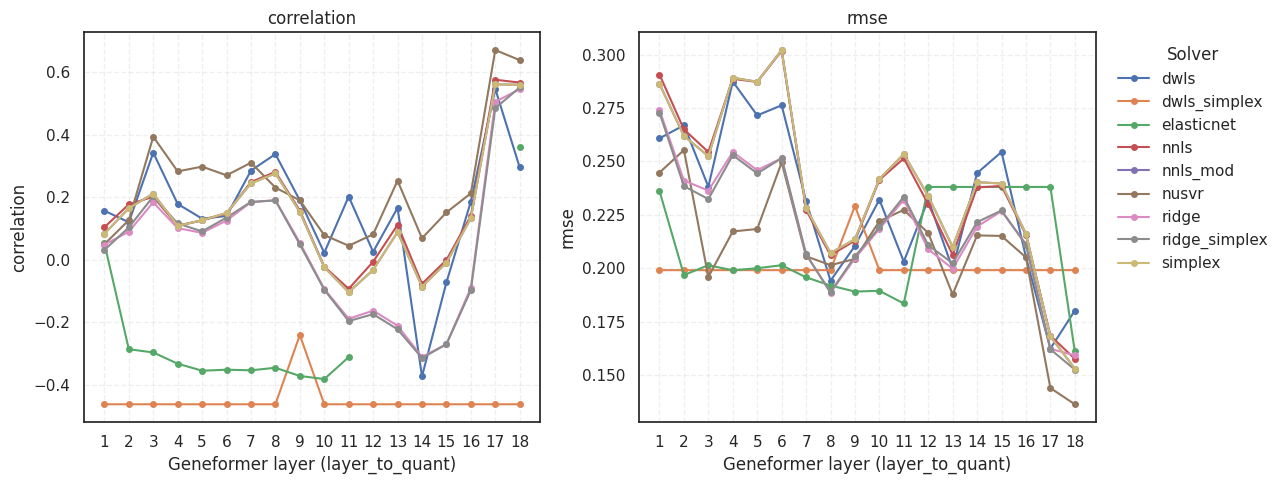

     layer         solver  correlation      rmse  meanCorrelation  meanRMSE
146     17           dwls     0.546695  0.162328         0.222817  0.146696
77       9   dwls_simplex    -0.240659  0.229179        -0.081209  0.201470
160     18     elasticnet     0.361859  0.161002         0.365733  0.132526
144     17           nnls     0.576046  0.168380         0.237024  0.152543
145     17       nnls_mod     0.561343  0.168047         0.186987  0.151454
152     17          nusvr     0.671044  0.143883         0.260631  0.132196
159     18          ridge     0.545491  0.159190         0.256070  0.142313
157     18  ridge_simplex     0.551565  0.152493         0.272160  0.137389
147     17        simplex     0.561342  0.168047         0.084329  0.151454


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['correlation', 'rmse']):
    for solver, sub in metrics_df.groupby('solver'):
        sub = sub.sort_values('layer')
        ax.plot(sub['layer'], sub[metric], marker='o', markersize=4, label=solver)
    ax.set_xlabel('Geneformer layer (layer_to_quant)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle='--')
axes[1].legend(title='Solver', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('../../results/layer_sweep_zeroshot_finotello.png', dpi=300, bbox_inches='tight')
plt.show()
print(metrics_df.loc[metrics_df.groupby('solver')['correlation'].idxmax()])

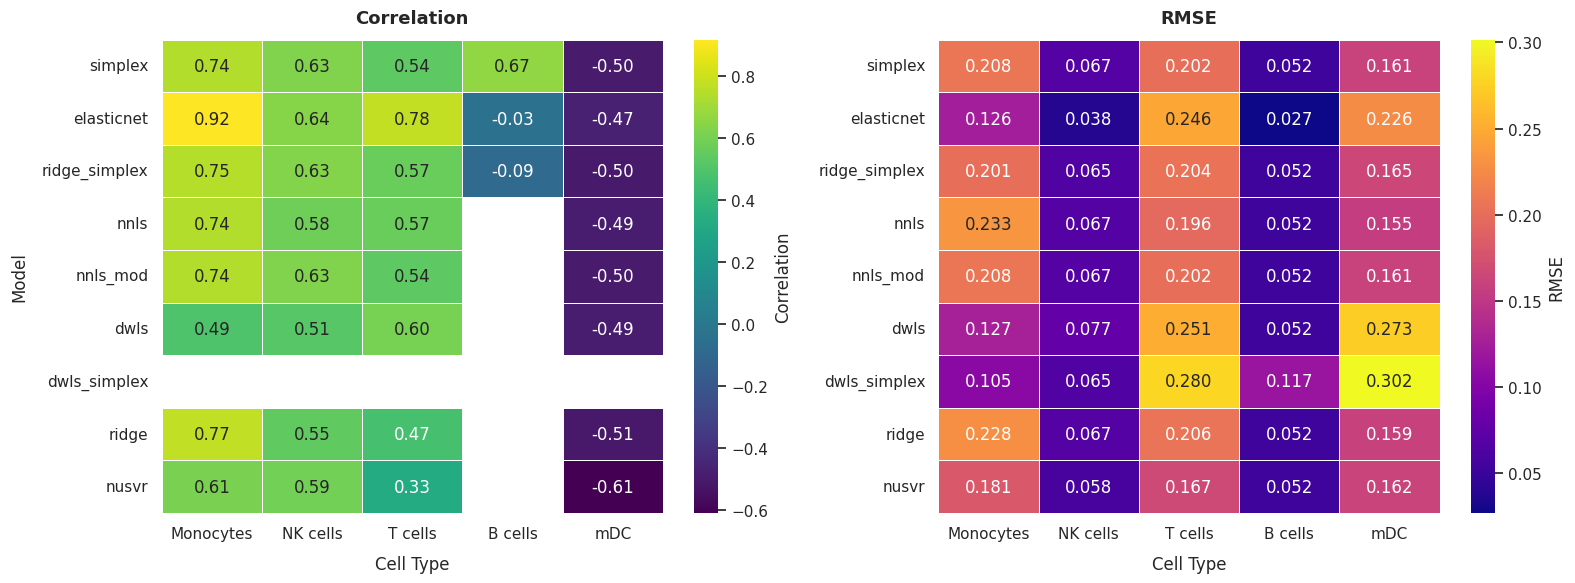

In [31]:
visualize_solvers(layer_results[18], ground_truth, level=["cell_type"])

In [35]:
ground_truth.shape

(12, 7)

In [33]:
# layer_results = {}
# metric_rows = []
# celltype_rows = []
# for layer in range(1, 19):
#     print(f'=== layer {layer} ===', flush=True)
#     sig_mat_gf_embed = extract_embs(
#         bulk_df=signature_df,
#         mode='geneformer',
#         temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
#         model_path='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/',
#         delete_temp_files=True,
#         layer_to_quant=layer,
#     )
#     gf_embed = extract_embs(
#         bulk_df=bulk_df,
#         mode='geneformer',
#         temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
#         model_path='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/',
#         delete_temp_files=True,
#         layer_to_quant=layer,
#     )
#     results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
#     results = {solver: harmonize_columns(df) for solver, df in results.items()}
#     layer_results[layer] = results
#     for solver, df in results.items():
#         samples = df.index.intersection(ground_truth.index)
#         celltypes = df.columns.intersection(ground_truth.columns)
#         P = df.loc[samples, celltypes].astype(float)
#         T = ground_truth.loc[samples, celltypes].astype(float)
#         p = P.values.ravel()
#         t = T.values.ravel()
#         ok = np.isfinite(p) & np.isfinite(t)
#         for ct in celltypes:
#             a = P[ct].values
#             b = T[ct].values
#             m = np.isfinite(a) & np.isfinite(b)
#             if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
#                 r_ct = np.corrcoef(a[m], b[m])[0, 1]
#             else:
#                 r_ct = np.nan
#             celltype_rows.append({'layer': layer, 'solver': solver, 'celltype': ct, 'correlation': r_ct, 'rmse': np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan})
#         ct_sub = [r for r in celltype_rows if r['layer'] == layer and r['solver'] == solver]
#         corrs = np.array([r['correlation'] for r in ct_sub], dtype=float)
#         mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
#         mean_rmse = np.nanmean([r['rmse'] for r in ct_sub])
#         metric_rows.append({'layer': layer, 'solver': solver, 'correlation': np.corrcoef(p[ok], t[ok])[0, 1], 'rmse': np.sqrt(np.mean((p[ok] - t[ok]) ** 2)), 'meanCorrelation': mean_corr, 'meanRMSE': mean_rmse})
# metrics_df = pd.DataFrame(metric_rows)
# celltype_df = pd.DataFrame(celltype_rows)
# metrics_df.to_csv('../../results/layer_sweep_metrics_finetuned_finotello.csv', index=False)

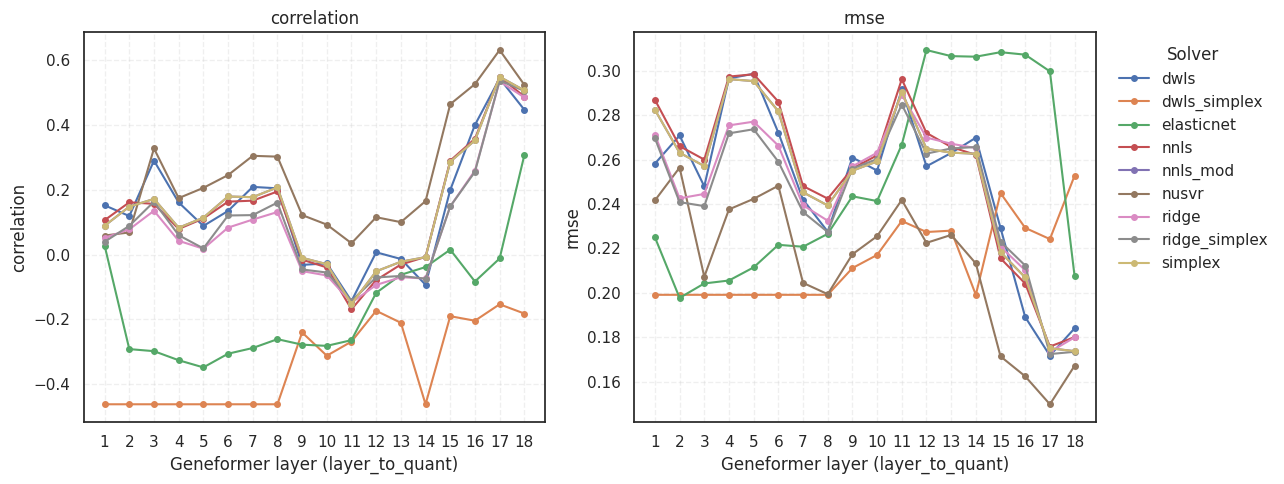

     layer         solver  correlation      rmse  meanCorrelation  meanRMSE
146     17           dwls     0.544034  0.171741         0.242367  0.155506
149     17   dwls_simplex    -0.153381  0.224179         0.016208  0.200731
160     18     elasticnet     0.306810  0.207463         0.336907  0.185114
144     17           nnls     0.549257  0.175812         0.281791  0.157600
145     17       nnls_mod     0.549400  0.175036         0.276079  0.156959
152     17          nusvr     0.631986  0.149827         0.232845  0.137684
150     17          ridge     0.535487  0.173379         0.252733  0.156736
148     17  ridge_simplex     0.537892  0.172429         0.154826  0.155841
147     17        simplex     0.549400  0.175036         0.212198  0.156959


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['correlation', 'rmse']):
    for solver, sub in metrics_df.groupby('solver'):
        sub = sub.sort_values('layer')
        ax.plot(sub['layer'], sub[metric], marker='o', markersize=4, label=solver)
    ax.set_xlabel('Geneformer layer (layer_to_quant)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle='--')
axes[1].legend(title='Solver', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('../../results/layer_sweep_finetuned_finotello.png', dpi=300, bbox_inches='tight')
plt.show()
print(metrics_df.loc[metrics_df.groupby('solver')['correlation'].idxmax()])